# Pipeline SARIMAX

### Informações do Grupo

##### Grupo: 4

Base: `jena_climate_2009_2016.csv`

Previsão da temperatura do ar na base Jena Climate.

- Granularidade: `horária` (agregação da base original de 10 minutos)
- Variável-alvo: `T (degC)`
- Random State (seed): `42`
- Treino-teste: `80% / 20%`

## Importações e Configurações Padrão

In [7]:
from pathlib import Path
import itertools
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "validacao_bases.py").is_file():
    PROJECT_ROOT = Path("/Users/sofia.santana/Documents/pipeline_ml")
sys.path.insert(0, str(PROJECT_ROOT))

from validacao_bases import carregar_base, relatorios_como_dataframe, validar_base
from funcoes_series_temporais import analisar_componente_residual, calcular_forca_sazonalidade

DATA_FILENAME = "jena_climate_2009_2016.csv"
DATA_PATH = PROJECT_ROOT / "grupo4" / DATA_FILENAME
DATE_COLUMN = "Date Time"
TARGET_COLUMN = "T (degC)"
FREQUENCY = "h"
SEED = 42
TRAIN_RATIO = 0.80
SEASONAL_PERIOD = 24

In [8]:
# Configuração específica do sarimax
ORDER = (2, 0, 2)
SEASONAL_ORDER = (1, 0, 1, SEASONAL_PERIOD)
TREND = "c"
EXOG_COLUMNS = ["p (mbar)", "rh (%)", "wv (m/s)", "wd (deg)"]
EXOG_LAG = 1
INFORMATION_CRITERION = "aic"
ENFORCE_STATIONARITY = False
ENFORCE_INVERTIBILITY = False

## Configuração do SARIMAX

In [9]:
# A configuração do grupo 4 está definida na seção anterior.
# Esta célula é mantida para preservar a estrutura do template.
print("Configuração do grupo 4 carregada.")

Configuração do grupo 4 carregada.


# 1. Preparação da base

## T01 — Sanitização e congelamento da base

Congelamento e validação sanitária da base: verificação de nulos, duplicatas, datas, ordenação e frequência regular.

In [10]:
# Validação somente leitura e preparação horária
relatorio = validar_base("clima", raiz=PROJECT_ROOT)
display(relatorios_como_dataframe({"clima": relatorio}))

df_bruto = carregar_base("clima", raiz=PROJECT_ROOT)
df_bruto[DATE_COLUMN] = pd.to_datetime(
    df_bruto[DATE_COLUMN], format="%d.%m.%Y %H:%M:%S", errors="coerce"
)
df_bruto = df_bruto.dropna(subset=[DATE_COLUMN]).sort_values(DATE_COLUMN)
df_bruto = df_bruto.drop_duplicates(subset=DATE_COLUMN).set_index(DATE_COLUMN)
df = df_bruto.select_dtypes(include="number").resample(FREQUENCY).mean()
df = df.interpolate(limit_direction="both")
print(f"Base: {DATA_FILENAME} | {len(df):,} observações horárias")
print(f"Período: {df.index.min()} a {df.index.max()}")

,nome,linhas,colunas,linhas_com_nulos,duplicatas_exatas,datas_invalidas,datas_duplicadas,ordenacao_datas,frequencia_esperada,frequencia_modelagem,frequencia_regular,timestamps_ausentes,timestamps_fora_da_grade,aprovada
0,clima,420551,15,0,327,0,327,não ordenada,10min,h,False,544,0,False


Base: jena_climate_2009_2016.csv | 70,129 observações horárias
Período: 2009-01-01 00:00:00 a 2017-01-01 00:00:00


## T02 — Dicionário de dados e disponibilidade temporal

Criação do dicionário de dados e análise de disponibilidade temporal das variáveis exógenas para prevenir data leakage.

In [12]:
# Dicionário simplificado e disponibilidade temporal
DICIONARIO = pd.DataFrame([
    {"variavel": coluna, "tipo": str(df[coluna].dtype),
     "disponibilidade": "não conhecida no futuro; usada com defasagem de 1 hora",
     "min": df[coluna].min(), "max": df[coluna].max(), "media": df[coluna].mean()}
    for coluna in [TARGET_COLUMN] + EXOG_COLUMNS
])
display(DICIONARIO.round(3))

,variavel,tipo,disponibilidade,min,max,media
0,T (degC),float64,não conhecida no futuro; usada com defasagem d...,-22.653,37.038,9.445
1,p (mbar),float64,não conhecida no futuro; usada com defasagem d...,934.905,1015.243,989.224
2,rh (%),float64,não conhecida no futuro; usada com defasagem d...,13.683,100.000,76.035
3,wv (m/s),float64,não conhecida no futuro; usada com defasagem d...,-9999.000,12.895,1.700
4,wd (deg),float64,não conhecida no futuro; usada com defasagem d...,0.000,359.800,174.827


## T03 — Análise exploratória visual

Análise visual do alvo e das variáveis exógenas, diagnóstico de outliers e registro das decisões de limpeza.

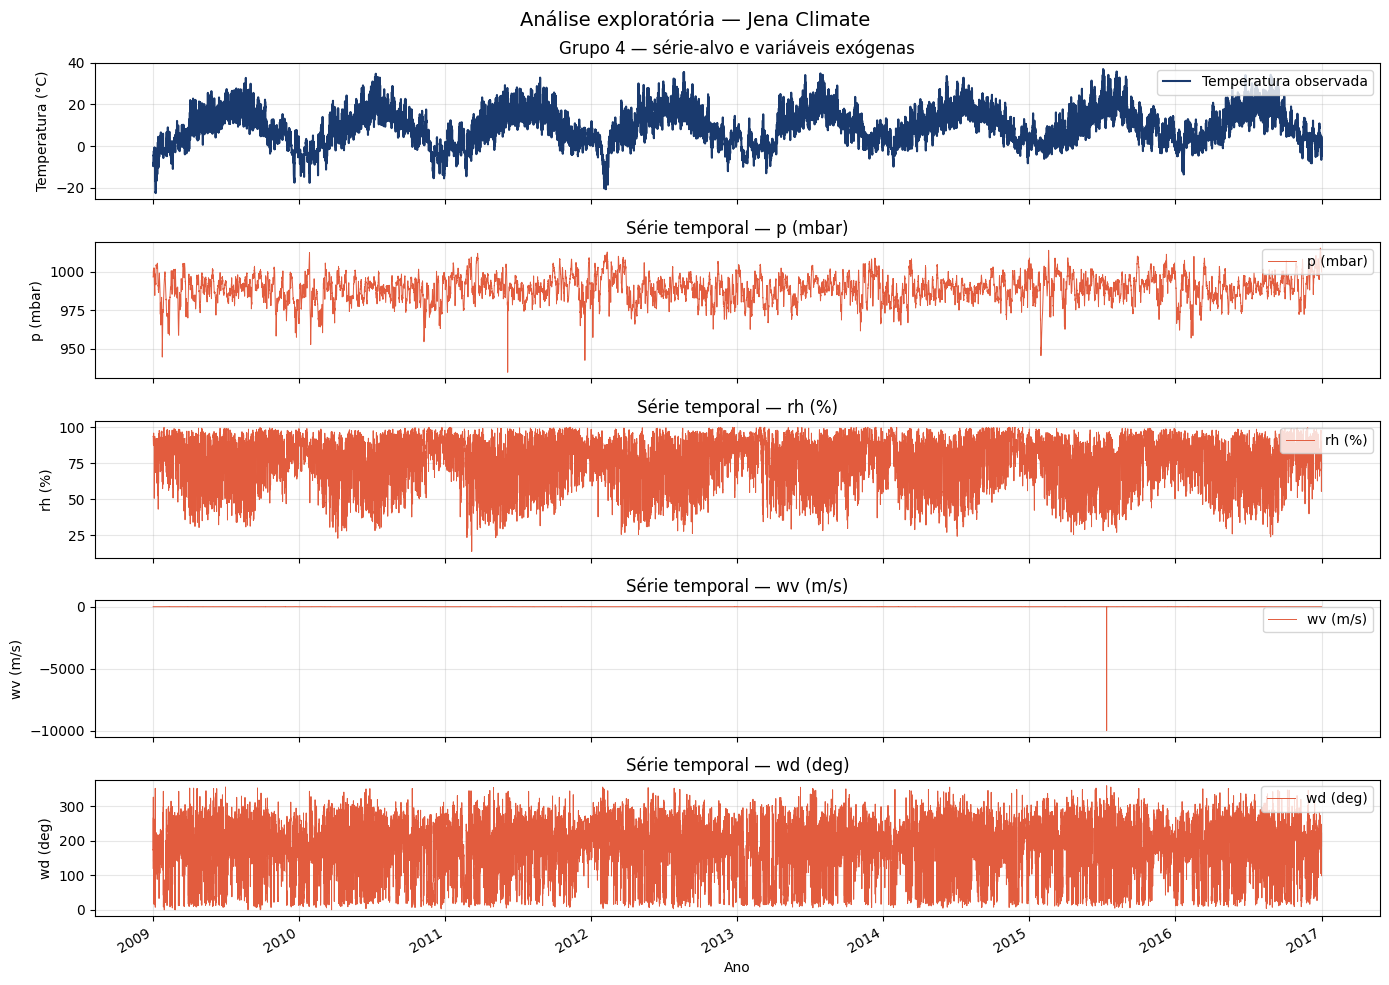

In [13]:
# T03 — análise exploratória visual
fig, axes = plt.subplots(
    len(EXOG_COLUMNS) + 1,
    1,
    figsize=(14, 10),
    sharex=True,
    squeeze=False,
)
axes = axes[:, 0]

axes[0].plot(
    df.index,
    df[TARGET_COLUMN],
    color="#1a3a6e",
    label="Temperatura observada",
)
axes[0].set_title("Grupo 4 — série-alvo e variáveis exógenas")
axes[0].set_ylabel("Temperatura (°C)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

for ax, coluna in zip(axes[1:], EXOG_COLUMNS):
    ax.plot(
        df.index,
        df[coluna],
        linewidth=0.7,
        color="#e25c3e",
        label=coluna,
    )
    ax.set_title(f"Série temporal — {coluna}")
    ax.set_ylabel(coluna)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Ano")
fig.suptitle("Análise exploratória — Jena Climate", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 2. Sazonalidade

## T04 — Decomposição STL

Decomposição STL e interpretação gráfica da tendência, incluindo períodos de alta, queda e estabilidade.

Força da sazonalidade: 0.6924
Força da tendência: 0.9581


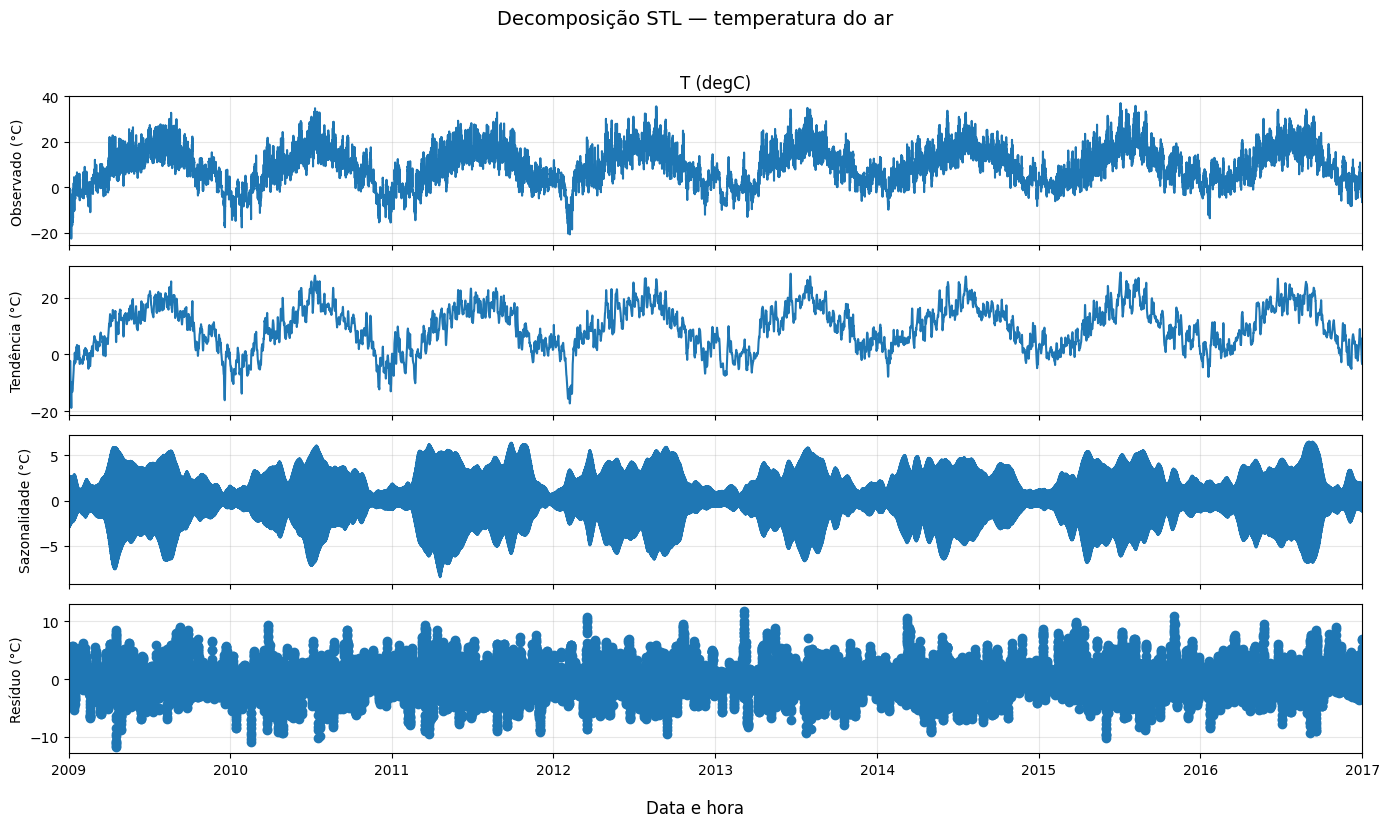

In [14]:
# Decomposição STL para a sazonalidade diária
stl_resultado = calcular_forca_sazonalidade( df[TARGET_COLUMN], periodo=SEASONAL_PERIOD)
decomposicao = stl_resultado["decomposicao"]
print(f"Força da sazonalidade: {stl_resultado['forca_sazonalidade']:.4f}")
print(f"Força da tendência: {stl_resultado['forca_tendencia']:.4f}")

fig = decomposicao.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Decomposição STL — temperatura do ar", fontsize=14, y=1.02)
fig.supxlabel("Data e hora")
fig.axes[0].set_ylabel("Observado (°C)")
fig.axes[1].set_ylabel("Tendência (°C)")
fig.axes[2].set_ylabel("Sazonalidade (°C)")
fig.axes[3].set_ylabel("Resíduo (°C)")
for ax in fig.axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## T05 — Força da sazonalidade e resíduos

Cálculo da força da sazonalidade e análise do componente residual.

Média do residual: -0.036092
Desvio-padrão do residual: 1.645967


,lb_stat,lb_pvalue
1,59815.157707,0.0
2,102796.167603,0.0
3,129902.530555,0.0
4,144465.493398,0.0
5,150641.149267,0.0
6,152279.443495,0.0
7,152341.504057,0.0
8,152676.955707,0.0
9,154129.939898,0.0
10,156766.616589,0.0


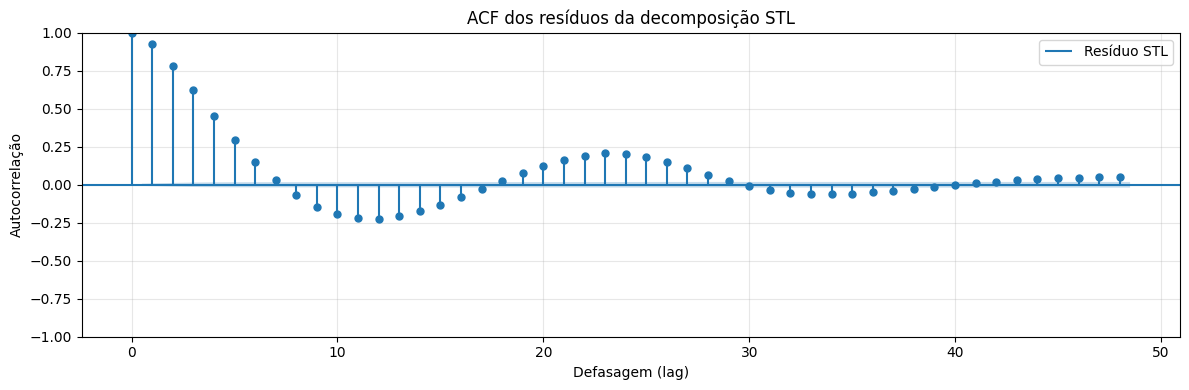

In [15]:
# Análise do componente residual
analise_residuos_stl = analisar_componente_residual(decomposicao, lags=24)
print(f"Média do residual: {analise_residuos_stl['media']:.6f}")
print(f"Desvio-padrão do residual: {analise_residuos_stl['desvio_padrao']:.6f}")
display(analise_residuos_stl["autocorrelacao_residual"])

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(
    analise_residuos_stl["residuo"],
    lags=48,
    ax=ax,
    title="ACF dos resíduos da decomposição STL",
)
ax.set_xlabel("Defasagem (lag)")
ax.set_ylabel("Autocorrelação")
ax.legend(["Resíduo STL"], loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Validação temporal

## T08 — Validação walk-forward

Implementação do protocolo walk-forward com janelas, origens de teste fixas e horizonte de previsão unificado.

In [16]:
# Preparação temporal e walk-forward com uma origem no limite treino-teste
features = pd.DataFrame(index=df.index)
for coluna in EXOG_COLUMNS:
    features[f"{coluna}_lag{EXOG_LAG}"] = df[coluna].shift(EXOG_LAG)

# Variáveis determinísticas conhecidas antecipadamente para a sazonalidade diária.
t = np.arange(len(df))
features["sin_diario"] = np.sin(2 * np.pi * t / SEASONAL_PERIOD)
features["cos_diario"] = np.cos(2 * np.pi * t / SEASONAL_PERIOD)

model_data = pd.concat([df[TARGET_COLUMN].rename("target"), features], axis=1).dropna()
n_train = int(len(model_data) * TRAIN_RATIO)
train = model_data.iloc[:n_train]
test = model_data.iloc[n_train:]
y_train, y_test = train["target"], test["target"]
X_train, X_test = train.drop(columns="target"), test.drop(columns="target")
print(f"Treino: {len(train):,} ({len(train) / len(model_data):.1%})")
print(f"Teste: {len(test):,} ({len(test) / len(model_data):.1%})")
print(f"Origem: {y_train.index[-1]} | horizonte: {len(test):,} horas")

Treino: 56,102 (80.0%)
Teste: 14,026 (20.0%)
Origem: 2015-05-27 14:00:00 | horizonte: 14,026 horas


# 4. Modelagem SARIMAX

## T10 — SARIMAX

Adaptação do SARIMAX com seleção de p, d, q, P, D, Q e m por AIC/BIC, inclusão segura de exógenas e execução walk-forward.

In [17]:
# Grid SARIMAX, seleção por MAE de validação e ajuste final
# O grid segue a lógica da pipeline original: testa todas as combinações,
# registra AIC/BIC e compara previsões fora da amostra.
p_range = [0, 1, 2]
q_range = [0, 1, 2]
P_range = [0, 1]
Q_range = [0, 1]
d_range = [0, 1]
D_range = [0, 1]
m_range = [SEASONAL_PERIOD]

combos_sarimax = list(
    itertools.product(p_range, d_range, q_range, P_range, D_range, Q_range, m_range)
)
print(f"Ranges: p={p_range} d={d_range} q={q_range}")
print(f"        P={P_range} D={D_range} Q={Q_range} m={m_range}")
print(f"Total de combinações SARIMAX: {len(combos_sarimax)}")

# A seleção usa somente o treino: a última parte do treino é validação.
n_validacao = max(24 * 7, int(len(y_train) * 0.20))
y_grid_train = y_train.iloc[:-n_validacao]
y_validacao = y_train.iloc[-n_validacao:]
X_grid_train = X_train.iloc[:-n_validacao]
X_validacao = X_train.iloc[-n_validacao:]

scaler_y_grid = StandardScaler()
scaler_x_grid = StandardScaler()
y_grid_train_sc = pd.Series(
    scaler_y_grid.fit_transform(y_grid_train.to_numpy().reshape(-1, 1)).ravel(),
    index=y_grid_train.index,
)
X_grid_train_sc = pd.DataFrame(
    scaler_x_grid.fit_transform(X_grid_train),
    index=X_grid_train.index,
    columns=X_grid_train.columns,
)
X_validacao_sc = pd.DataFrame(
    scaler_x_grid.transform(X_validacao),
    index=X_validacao.index,
    columns=X_validacao.columns,
)

sarimax_grid = []
for i, (p, d, q, P, D, Q, m) in enumerate(combos_sarimax, start=1):
    if d + D == 0 and p + q + P + Q == 0:
        continue
    n_efetivo = len(y_grid_train) - d - D * m
    if n_efetivo < max(p, P * m) + 10:
        continue
    try:
        modelo_grid = SARIMAX(
            y_grid_train_sc,
            exog=X_grid_train_sc,
            order=(p, d, q),
            seasonal_order=(P, D, Q, m),
            trend=TREND,
            enforce_stationarity=ENFORCE_STATIONARITY,
            enforce_invertibility=ENFORCE_INVERTIBILITY,
        ).fit(disp=False, maxiter=100)
        previsao_sc = np.asarray(
            modelo_grid.get_forecast(
                steps=len(y_validacao), exog=X_validacao_sc
            ).predicted_mean
        )
        previsao_validacao = scaler_y_grid.inverse_transform(
            previsao_sc.reshape(-1, 1)
        ).ravel()
        mae_validacao = mean_absolute_error(y_validacao, previsao_validacao)
        sarimax_grid.append({
            "order": (p, d, q),
            "seasonal_order": (P, D, Q, m),
            "AIC": modelo_grid.aic,
            "BIC": modelo_grid.bic,
            "MAE_validacao": mae_validacao,
        })
    except Exception as exc:
        print(f"Combinação {(p, d, q, P, D, Q, m)} falhou: {type(exc).__name__}")
    if i % max(1, len(combos_sarimax) // 10) == 0:
        print(f"  {i}/{len(combos_sarimax)} combinações testadas...")

if not sarimax_grid:
    raise RuntimeError("Nenhuma combinação SARIMAX convergiu no grid.")

df_sarimax_grid = (
    pd.DataFrame(sarimax_grid)
    .sort_values(["MAE_validacao", "AIC"])
    .reset_index(drop=True)
)
print(f"\nModelos convergidos: {len(df_sarimax_grid)} de {len(combos_sarimax)}")
print("TOP 10 — grid SARIMAX ordenado por MAE de validação:")
display(df_sarimax_grid.head(10))

melhor_linha = df_sarimax_grid.iloc[0]
ORDER = tuple(melhor_linha["order"])
SEASONAL_ORDER = tuple(melhor_linha["seasonal_order"])
print(f"\nMelhor configuração na validação: order={ORDER} | seasonal_order={SEASONAL_ORDER}")
print(f"MAE de validação: {melhor_linha['MAE_validacao']:.4f}")

Ranges: p=[0, 1, 2] d=[0, 1] q=[0, 1, 2]
        P=[0, 1] D=[0, 1] Q=[0, 1] m=[24]
Total de combinações SARIMAX: 144
  14/144 combinações testadas...
  28/144 combinações testadas...


/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  42/144 combinações testadas...


/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  56/144 combinações testadas...


...

  140/144 combinações testadas...


/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Modelos convergidos: 143 de 144
TOP 10 — grid SARIMAX ordenado por MAE de validação:


,order,seasonal_order,AIC,BIC,MAE_validacao
0,"(0, 0, 1)","(0, 0, 0, 24)",55688.926432,55767.332160,5.086974
1,"(0, 0, 0)","(0, 0, 1, 24)",75406.044301,75484.445416,5.105665
2,"(0, 0, 0)","(1, 0, 0, 24)",25383.824362,25462.225677,5.173845
3,"(0, 0, 0)","(1, 0, 1, 24)",25316.100400,25403.212749,5.174781
4,"(0, 0, 1)","(0, 0, 1, 24)",24383.713707,24470.825834,5.222644
5,"(0, 0, 1)","(1, 0, 0, 24)",-20751.202682,-20664.090110,5.267266
6,"(0, 0, 1)","(1, 0, 1, 24)",-21449.704794,-21353.881455,5.269015
7,"(0, 0, 2)","(0, 0, 0, 24)",15913.593072,16000.710324,5.298930
8,"(1, 0, 0)","(0, 0, 0, 24)",-97869.517546,-97791.111618,5.305461
9,"(1, 0, 0)","(0, 0, 1, 24)",-100467.068270,-100379.955921,5.359654



Melhor configuração na validação: order=(0, 0, 1) | seasonal_order=(0, 0, 0, 24)
MAE de validação: 5.0870


# 5. Avaliação

## T16 — Comparação por MAE

Consolidação do MAE fora da amostra por base e modelo, incluindo número de vitórias e posição média.

In [18]:
# Refit do melhor SARIMAX no treino completo e avaliação no teste final
# Os hiperparâmetros foram congelados pelo grid antes de tocar no teste.
scaler_y = StandardScaler()
scaler_x = StandardScaler()
y_train_scaled = pd.Series(
    scaler_y.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel(),
    index=y_train.index,
    name="target",
)
X_train_scaled = pd.DataFrame(
    scaler_x.fit_transform(X_train), index=X_train.index, columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler_x.transform(X_test), index=X_test.index, columns=X_test.columns
)

modelo = SARIMAX(
    y_train_scaled,
    exog=X_train_scaled,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=ENFORCE_STATIONARITY,
    enforce_invertibility=ENFORCE_INVERTIBILITY,
).fit(disp=False, maxiter=100)
resultado = modelo

previsao_resultado = modelo.get_forecast(steps=len(test), exog=X_test_scaled)
previsao = scaler_y.inverse_transform(
    np.asarray(previsao_resultado.predicted_mean).reshape(-1, 1)
).ravel()
intervalo_scaled = np.asarray(previsao_resultado.conf_int(alpha=0.05))
intervalo = scaler_y.inverse_transform(intervalo_scaled)
erros = y_test.to_numpy() - previsao

metricas = pd.DataFrame([{
    "base": "clima",
    "modelo": f"SARIMAX {ORDER}{SEASONAL_ORDER}",
    "AIC": modelo.aic,
    "BIC": modelo.bic,
    "MAE": mean_absolute_error(y_test, previsao),
    "RMSE": mean_squared_error(y_test, previsao) ** 0.5,
    "ME_vies": erros.mean(),
}])
display(metricas.round(4))

,base,modelo,AIC,BIC,MAE,RMSE,ME_vies
0,clima,"SARIMAX (0, 0, 1)(0, 0, 0, 24)",70470.0415,70550.4556,6.1827,43.7846,1.5129


## T17 — Diagnóstico dos resíduos

Análise gráfica e estatística dos resíduos com série temporal dos erros, ACF, teste de Ljung-Box e tabela de p-valores.

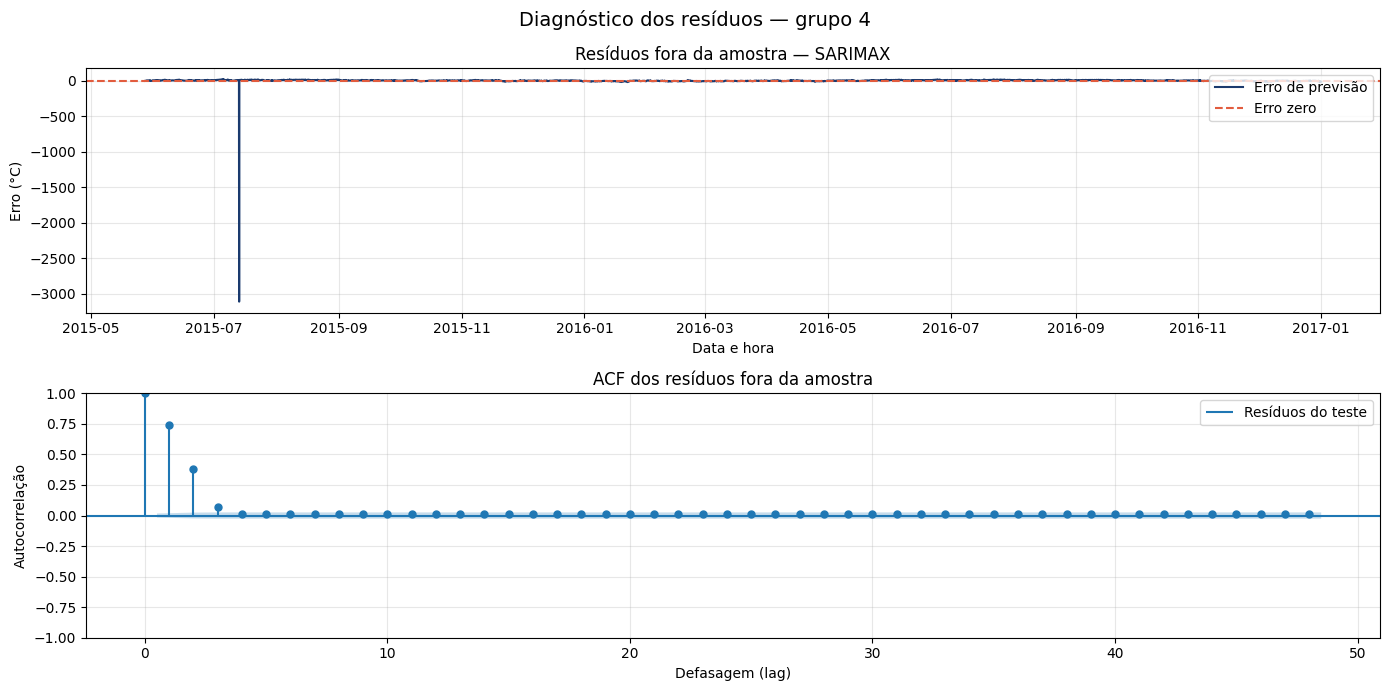

,lb_stat,lb_pvalue
1,7655.014467,0.0
2,9649.760281,0.0
3,9710.582553,0.0
4,9713.945937,0.0
5,9717.074540,0.0
6,9719.895073,0.0
7,9722.531685,0.0
8,9725.095310,0.0
9,9727.564399,0.0
10,9729.901644,0.0


Viés médio: 1.5129


In [19]:
# Diagnóstico dos resíduos fora da amostra
residuos_teste = pd.Series(erros, index=y_test.index, name="residuo")
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
axes[0].plot(
    residuos_teste.index,
    residuos_teste,
    color="#1a3a6e",
    label="Erro de previsão",
)
axes[0].axhline(0, color="#e25c3e", linestyle="--", label="Erro zero")
axes[0].set_title("Resíduos fora da amostra — SARIMAX")
axes[0].set_ylabel("Erro (°C)")
axes[0].set_xlabel("Data e hora")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

plot_acf(
    residuos_teste,
    lags=48,
    ax=axes[1],
    title="ACF dos resíduos fora da amostra",
)
axes[1].set_xlabel("Defasagem (lag)")
axes[1].set_ylabel("Autocorrelação")
axes[1].legend(["Resíduos do teste"], loc="upper right")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Diagnóstico dos resíduos — grupo 4", fontsize=14)
plt.tight_layout()
plt.show()
analise_residuos_teste = analisar_componente_residual(
    type("Decomposicao", (), {"resid": residuos_teste})(), lags=24
)
display(analise_residuos_teste["autocorrelacao_residual"])
print(f"Viés médio: {residuos_teste.mean():.4f}")

## T18 — Importância das features

Cálculo e interpretação da importância das features: permutation importance para modelos de tabela e coeficientes para o SARIMAX.

In [20]:
# Coeficientes das exógenas padronizadas
coeficientes = pd.DataFrame({
    "variavel": X_train.columns,
    "coeficiente": [resultado.params.get(coluna, np.nan) for coluna in X_train.columns],
    "p_valor": [resultado.pvalues.get(coluna, np.nan) for coluna in X_train.columns],
})
coeficientes["importancia_absoluta"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values("importancia_absoluta", ascending=False)
display(coeficientes)

,variavel,coeficiente,p_valor,importancia_absoluta
1,rh (%)_lag1,-0.470789,0.000000e+00,0.470789
5,cos_diario,-0.076123,1.285337e-86,0.076123
0,p (mbar)_lag1,-0.065712,3.813966e-76,0.065712
2,wv (m/s)_lag1,-0.053968,2.526944e-89,0.053968
4,sin_diario,0.005867,1.456125e-01,0.005867
3,wd (deg)_lag1,0.003696,3.222068e-02,0.003696
